# Waste Management in the Republic of Ireland (2021-2024)

## Notebook purpose
This notebook analyses four EPA waste datasets (2021, 2022, 2023 and 2024) and builds a **regression model** to predict **Waste Quantity Tonnes per Year**.

## Structure
1. Load and merge the four CSV files  
2. Data quality checks and missing value review  
3. Exploratory Data Analysis (EDA) with descriptive statistics and plots  
4. Statistical analysis using:
   - Binomial distribution
   - Poisson distribution
   - Normal distribution  
5. Data preparation for machine learning  
6. Regression modelling with two tuned models  
7. Model comparison, interpretation and conclusions  

## Project focus
**Chosen area of interest:** Waste movement and treatment recorded by licensed facilities in Ireland.  
**Target variable:** `Waste Quantity Tonnes per Year`  

This is a suitable regression target because it is numeric, meaningful for planning and policy, and available across a large part of the merged data.

## Source files used
- `EPA-Licensee-Waste-Data-2021(1).csv`
- `EPA-Licensee-Waste-Data-2022(1).csv`
- `EPA-Licensee-Waste-Data-2023(1).csv`
- `EPA-Licensee-Waste-Data-2024(1).csv`

## Notes on approach
- The code is intentionally kept simple and readable.
- Markdown cells explain each step and justify the decisions.
- All statistics, plots and machine learning steps are carried out in Python.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import binom, poisson, norm

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

## 1. Business understanding and project framework

For this type of data science project, **CRISP-DM** is the most suitable framework.

### Why CRISP-DM?
- It starts with the business question, which fits this assessment well.
- It has clear stages: business understanding, data understanding, data preparation, modelling, evaluation and deployment.
- It works well for real projects where the data is messy and decisions must be justified.

### Why not KDD or SEMMA here?
- **KDD** is useful, but CRISP-DM gives a clearer full project workflow for an academic report.
- **SEMMA** is model-focused, but this assessment also strongly emphasises understanding, preparation, explanation and interpretation.

### Machine learning choice
I selected a **supervised learning** approach because the target variable (`Waste Quantity Tonnes per Year`) is already known for many observations and the goal is to predict a numeric outcome.

In [4]:
def load_and_tag(path, year):
    df = pd.read_csv(path)
    df["File Year"] = year
    return df

files = {
    2021: "EPA-Licensee-Waste-Data-2021.csv",
    2022: "EPA-Licensee-Waste-Data-2022.csv",
    2023: "EPA-Licensee-Waste-Data-2023.csv",
    2024: "EPA-Licensee-Waste-Data-2024.csv",
}

frames = [load_and_tag(name, year) for year, name in files.items()]
waste_df = pd.concat(frames, ignore_index=True)

print("Merged shape:", waste_df.shape)
print("Columns:")
print(list(waste_df.columns))

Merged shape: (31028, 16)
Columns:
['Reporting Year', 'Licence Profile', 'Waste Source', 'Waste Action', 'List of Waste Code', 'Low Code Description', 'Respondent Waste Description', 'Accepted Waste Quantity', 'Accepted waste quantity from abroad', 'Accepted Waste Quantity from Ireland', 'On Site Waste Treatment Type', 'Waste Quantity Tonnes per Year', 'Next Destination Waste Treatment Type', 'Final Destination Abroad', 'Final Destination Waste Treatment Type', 'File Year']


In [5]:
waste_df.head()

,Reporting Year,Licence Profile,Waste Source,Waste Action,List of Waste Code,Low Code Description,Respondent Waste Description,Accepted Waste Quantity,Accepted waste quantity from abroad,Accepted Waste Quantity from Ireland,On Site Waste Treatment Type,Waste Quantity Tonnes per Year,Next Destination Waste Treatment Type,Final Destination Abroad,Final Destination Waste Treatment Type,File Year
0,2021,Ashgrove Recycling - W0147,Waste Accepted,Waste Accepted,15 01 01,paper and cardboard packaging,Cardboard,40.58,0.0,40.58,R13 - Storage of waste pending any of the oper...,NaN,NaN,NaN,NaN,2021
1,2021,Ashgrove Recycling - W0147,Accepted,Transferred,15 01 01,paper and cardboard packaging,Cardboard,NaN,NaN,NaN,NaN,97.88,R13 - Storage of waste pending any of the oper...,NaN,NaN,2021
2,2021,Ashgrove Recycling - W0147,Waste Accepted,Waste Accepted,15 01 02,plastic packaging,plastic packaging,0.06,0.0,0.06,R13 - Storage of waste pending any of the oper...,NaN,NaN,NaN,NaN,2021
3,2021,Ashgrove Recycling - W0147,Accepted,Transferred,15 01 02,plastic packaging,Plastic Packaging,NaN,NaN,NaN,NaN,7.64,R13 - Storage of waste pending any of the oper...,NaN,NaN,2021
4,2021,Ashgrove Recycling - W0147,Waste Accepted,Waste Accepted,15 01 03,wooden packaging,wooden packaging,0.26,0.0,0.26,R13 - Storage of waste pending any of the oper...,NaN,NaN,NaN,NaN,2021


## 2. Initial data quality checks

The first task is to check:
- shape of the merged dataset
- duplicate rows
- fully empty rows
- missing values by column

This is important because the brief specifically asks for careful data preparation and justification.

In [7]:
duplicate_rows = waste_df.duplicated().sum()
all_empty_rows = waste_df.isna().all(axis=1).sum()

print("Duplicate rows:", duplicate_rows)
print("Fully empty rows:", all_empty_rows)

Duplicate rows: 13
Fully empty rows: 0


In [8]:
missing_summary = pd.DataFrame({
    "Missing Count": waste_df.isna().sum(),
    "Missing %": (waste_df.isna().mean() * 100).round(2),
    "Data Type": waste_df.dtypes.astype(str)
}).sort_values("Missing %", ascending=False)

missing_summary

,Missing Count,Missing %,Data Type
Next Destination Waste Treatment Type,25541,82.32,object
Final Destination Waste Treatment Type,18491,59.59,object
Accepted Waste Quantity,18089,58.30,float64
Accepted waste quantity from abroad,18089,58.30,float64
Accepted Waste Quantity from Ireland,18089,58.30,float64
Final Destination Abroad,17765,57.25,object
On Site Waste Treatment Type,17191,55.40,object
Waste Quantity Tonnes per Year,12940,41.70,float64
Respondent Waste Description,361,1.16,object
Reporting Year,0,0.00,int64


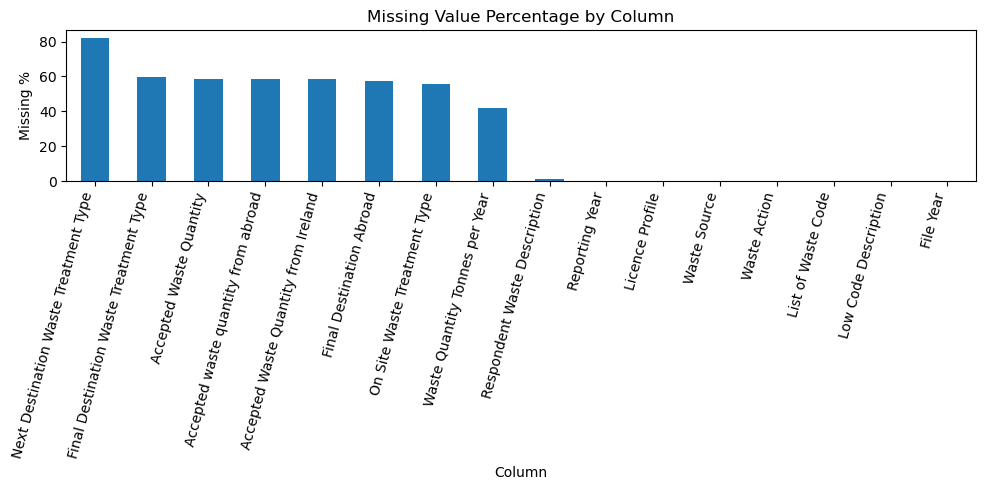

In [9]:
ax = missing_summary["Missing %"].plot(kind="bar")
plt.title("Missing Value Percentage by Column")
plt.ylabel("Missing %")
plt.xlabel("Column")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

### Missing value interpretation

A large number of missing values does exist, but they are **not all bad data**.

Several missing fields appear to be **structural missingness**, meaning they are empty because the row relates to a different operational stage.

For example:
- `Accepted Waste Quantity` is relevant when waste is accepted.
- `Waste Quantity Tonnes per Year` is relevant when waste is transferred or finally treated.
- Destination treatment columns are only relevant for some records.

So the correct response is **not** to automatically delete everything with missing values.  
Instead, each column must be judged in context.

In [11]:
# Check how the target behaves
target_rows = waste_df[waste_df["Waste Quantity Tonnes per Year"].notna()].copy()

print("Rows with target available:", target_rows.shape[0])
print("Waste Action distribution for target rows:")
print(target_rows["Waste Action"].value_counts(dropna=False))

print("Non-missing counts in accepted quantity columns for target rows:")
for col in ["Accepted Waste Quantity", "Accepted waste quantity from abroad", "Accepted Waste Quantity from Ireland"]:
    print(col, ":", target_rows[col].notna().sum())

Rows with target available: 18088
Waste Action distribution for target rows:
Waste Action
Transferred        17189
Finally Treated      898
Waste Accepted         1
Name: count, dtype: int64
Non-missing counts in accepted quantity columns for target rows:
Accepted Waste Quantity : 0
Accepted waste quantity from abroad : 0
Accepted Waste Quantity from Ireland : 0


The check above is very important for modelling.

For rows where the target exists, the three accepted-quantity columns are effectively unusable because they are empty for the model subset.  
These will therefore be removed from the regression feature set.

## 3. Descriptive statistics and EDA

The brief requires descriptive statistics and at least three graphs.

The visualisations below follow simple good design choices inspired by **Tufte's principles**:
- clear titles and axis labels
- no unnecessary decoration
- sorted categories where possible
- direct focus on the data, not chart effects
- readable scales and uncluttered layout

In [14]:
target_rows["Waste Quantity Tonnes per Year"].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
Waste Quantity Tonnes per Year,18088.0,2403.903549,22694.268481,0.0,8.0,53.4,376.79,1499662.0


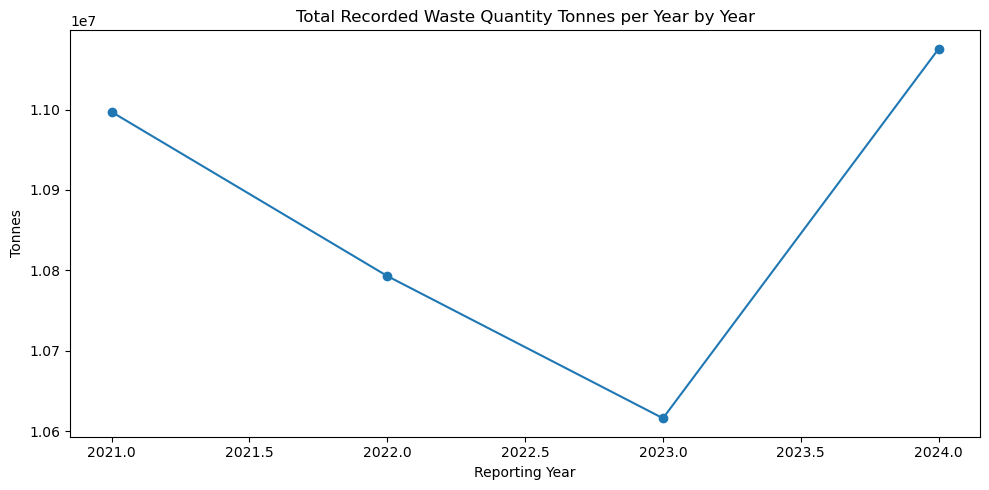

In [15]:
yearly_target = (
    target_rows.groupby("Reporting Year")["Waste Quantity Tonnes per Year"]
    .sum()
    .sort_index()
)

yearly_target.plot(marker="o")
plt.title("Total Recorded Waste Quantity Tonnes per Year by Year")
plt.ylabel("Tonnes")
plt.xlabel("Reporting Year")
plt.tight_layout()
plt.show()

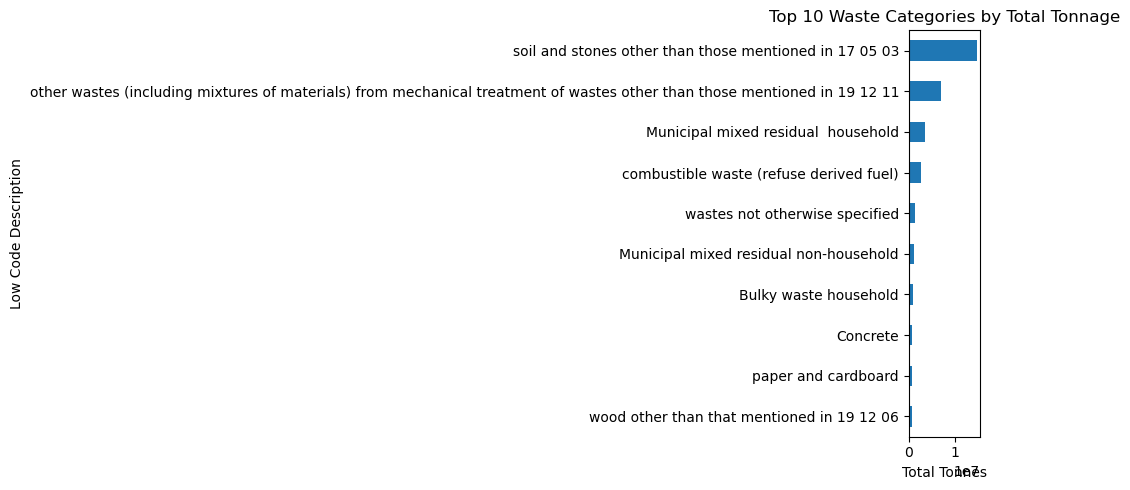

In [16]:
top_categories = (
    target_rows.groupby("Low Code Description")["Waste Quantity Tonnes per Year"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

top_categories.plot(kind="barh")
plt.title("Top 10 Waste Categories by Total Tonnage")
plt.xlabel("Total Tonnes")
plt.ylabel("Low Code Description")
plt.tight_layout()
plt.show()

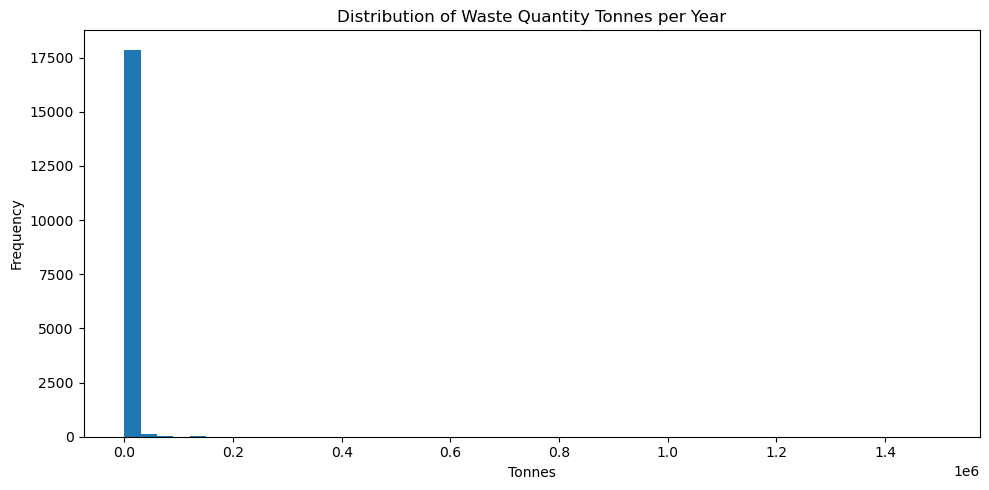

Skewness: 36.17


In [17]:
plt.hist(target_rows["Waste Quantity Tonnes per Year"], bins=50)
plt.title("Distribution of Waste Quantity Tonnes per Year")
plt.xlabel("Tonnes")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Skewness:", round(target_rows["Waste Quantity Tonnes per Year"].skew(), 2))

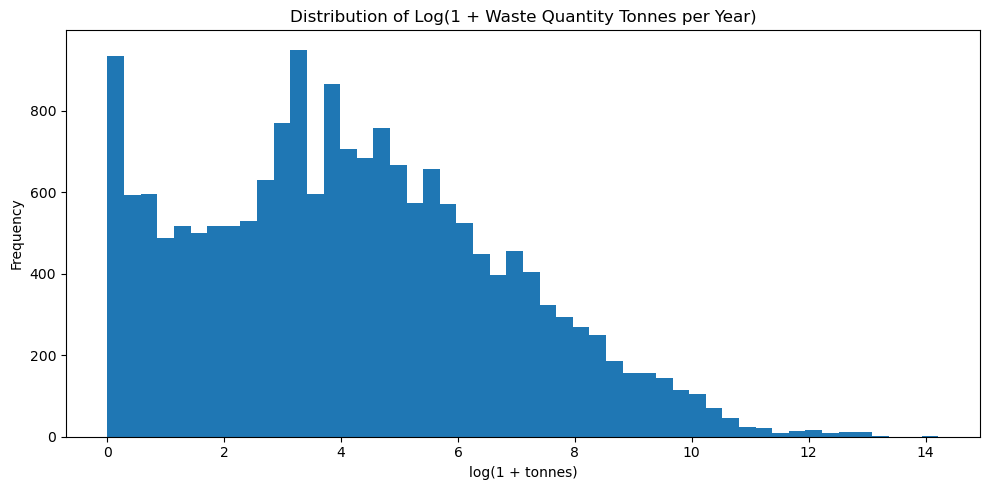

In [18]:
target_rows["Log Waste Quantity"] = np.log1p(target_rows["Waste Quantity Tonnes per Year"])

plt.hist(target_rows["Log Waste Quantity"], bins=50)
plt.title("Distribution of Log(1 + Waste Quantity Tonnes per Year)")
plt.xlabel("log(1 + tonnes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### EDA findings

From the plots and descriptive statistics:
- The target is **extremely right-skewed**.
- A small number of very large tonnage records dominate the distribution.
- The log transform makes the target more stable and closer to a bell-shaped form.
- Waste categories are unevenly distributed, with a few categories contributing much more tonnage than others.

This justifies using `log1p(target)` during modelling.

## 4. Statistical analysis using probability distributions

The assignment asks for:
- Binomial distribution
- Poisson distribution
- Normal distribution

The chosen variables are:

1. **Binomial:** whether final destination is abroad (`Yes/No`)  
2. **Poisson:** count of `Finally Treated` records per licence per year  
3. **Normal:** log-transformed `Waste Quantity Tonnes per Year`

These choices are justified because:
- Binomial is suitable for a binary outcome.
- Poisson is suitable for count data.
- Normal is more suitable for a continuous variable, especially after transformation.

### 4.1 Binomial distribution

A binomial variable counts the number of successes in a fixed number of trials.

Here, a "success" means a record with `Final Destination Abroad = Yes`.

This is reasonable because:
- each record is treated as a trial
- the outcome is binary (Yes/No)
- the estimated probability can be learned from the data

Estimated probability of final destination abroad: 0.5136
Number of records used: 13263
Probability of exactly 60 out of 100 being abroad: 0.018012
Probability of at least 60 out of 100 being abroad: 0.051319


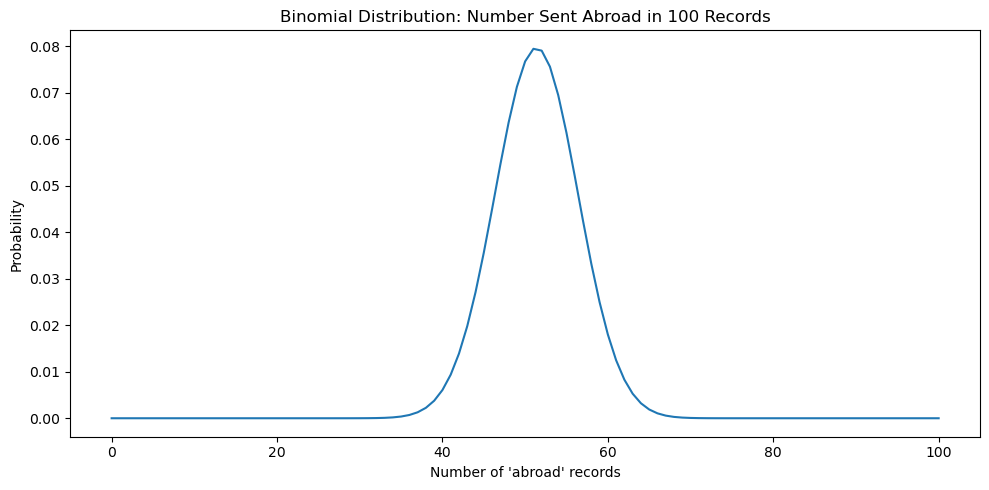

In [22]:
binom_df = waste_df[waste_df["Final Destination Abroad"].notna()].copy()
binom_df["abroad_flag"] = (
    binom_df["Final Destination Abroad"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"yes": 1, "no": 0})
)

p_hat = binom_df["abroad_flag"].mean()
n_binom = 100
x = np.arange(0, n_binom + 1)
pmf = binom.pmf(x, n=n_binom, p=p_hat)

print("Estimated probability of final destination abroad:", round(p_hat, 4))
print("Number of records used:", len(binom_df))
print("Probability of exactly 60 out of 100 being abroad:", round(binom.pmf(60, n=n_binom, p=p_hat), 6))
print("Probability of at least 60 out of 100 being abroad:", round(1 - binom.cdf(59, n=n_binom, p=p_hat), 6))

plt.plot(x, pmf)
plt.title("Binomial Distribution: Number Sent Abroad in 100 Records")
plt.xlabel("Number of 'abroad' records")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()

**Interpretation**

The estimated probability is close to 0.5, so the binomial distribution is fairly symmetric around its centre.

### Large sample behaviour
When the sample size becomes large, the binomial distribution starts to look more bell-shaped.  
This is one reason why large-sample binary outcomes are often approximated by the normal distribution.

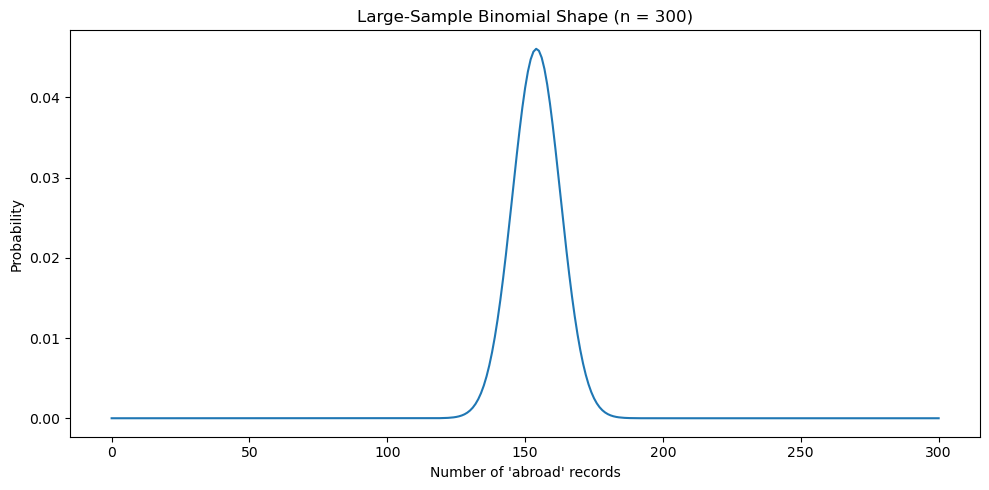

In [24]:
n_large = 300
x_large = np.arange(0, n_large + 1)
pmf_large = binom.pmf(x_large, n=n_large, p=p_hat)

plt.plot(x_large, pmf_large)
plt.title("Large-Sample Binomial Shape (n = 300)")
plt.xlabel("Number of 'abroad' records")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()

### 4.2 Poisson distribution

A Poisson distribution is used for count data.

Here, I count the number of `Finally Treated` records per `Licence Profile` per year.  
This is a count variable, so Poisson is a reasonable model to test.

Number of licence-year count observations: 233
Estimated lambda (mean count): 3.8584
Observed variance: 29.5704


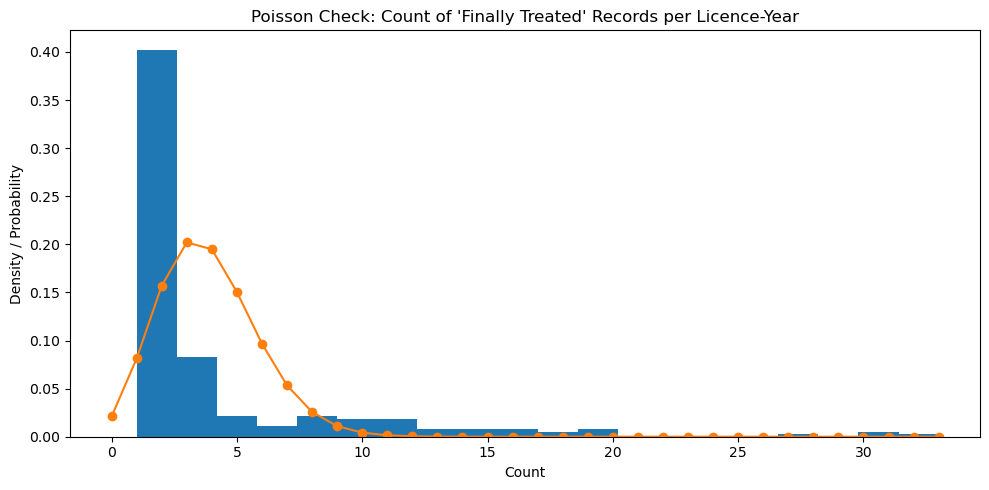

In [26]:
treated_counts = (
    waste_df[waste_df["Waste Action"] == "Finally Treated"]
    .groupby(["Reporting Year", "Licence Profile"])
    .size()
)

lambda_hat = treated_counts.mean()

print("Number of licence-year count observations:", len(treated_counts))
print("Estimated lambda (mean count):", round(lambda_hat, 4))
print("Observed variance:", round(treated_counts.var(), 4))

k = np.arange(0, treated_counts.max() + 1)
poisson_pmf = poisson.pmf(k, mu=lambda_hat)

plt.hist(treated_counts, bins=20, density=True)
plt.plot(k, poisson_pmf, marker="o")
plt.title("Poisson Check: Count of 'Finally Treated' Records per Licence-Year")
plt.xlabel("Count")
plt.ylabel("Density / Probability")
plt.tight_layout()
plt.show()

**Interpretation**

The Poisson model captures the idea of count data, but the observed variance is much larger than the mean.  
That indicates **overdispersion**, so the fit is not perfect.

### Large sample behaviour
As the Poisson mean gets larger, the Poisson distribution becomes more symmetric and starts to resemble the normal distribution.  
This is another useful bridge between discrete and continuous approximations.

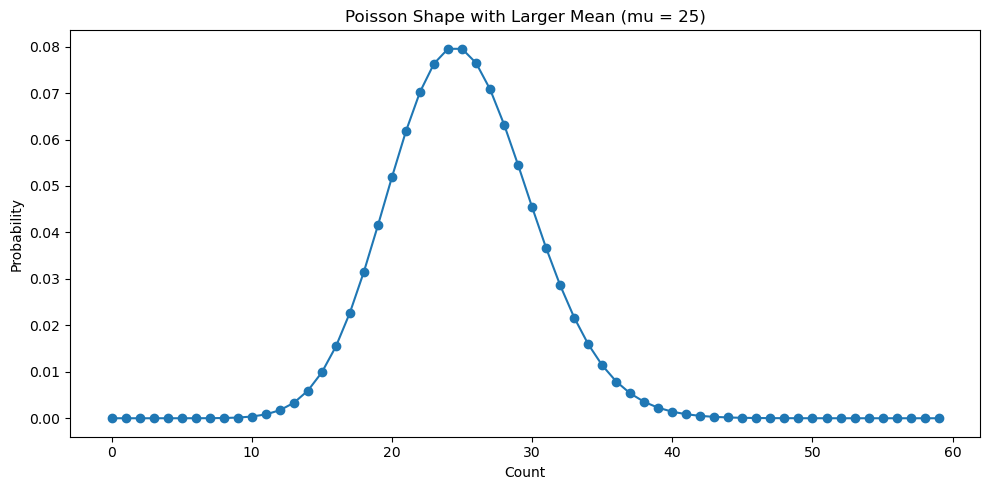

In [28]:
mu_large = 25
k_large = np.arange(0, 60)
poisson_large = poisson.pmf(k_large, mu=mu_large)

plt.plot(k_large, poisson_large, marker="o")
plt.title("Poisson Shape with Larger Mean (mu = 25)")
plt.xlabel("Count")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()

### 4.3 Normal distribution

A normal distribution is appropriate for continuous variables that are approximately symmetric.

The raw target is not close to normal because it is extremely right-skewed.  
However, `log(1 + Waste Quantity Tonnes per Year)` is much more suitable.

Mean of log target: 4.1961
Standard deviation of log target: 2.6036


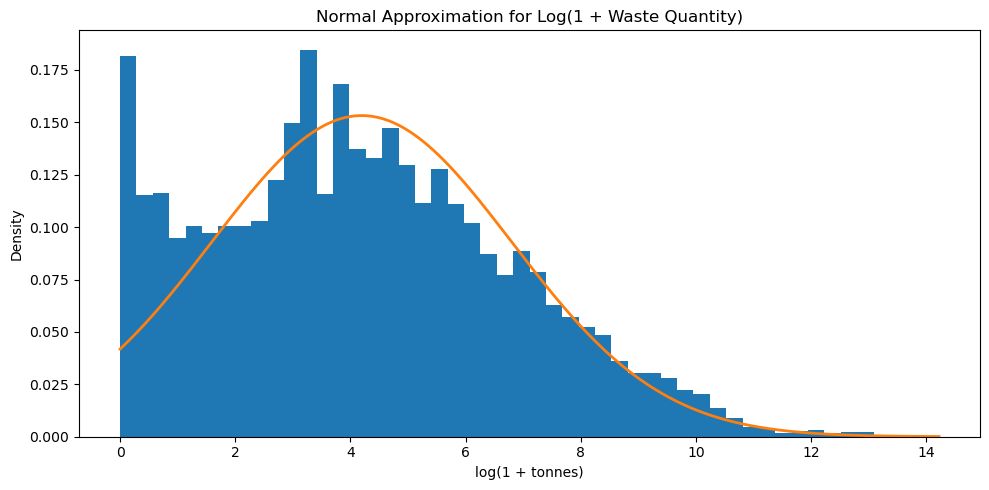

Share of observations within 1 standard deviation: 0.6374


In [30]:
log_target = target_rows["Log Waste Quantity"]
mu = log_target.mean()
sigma = log_target.std()

print("Mean of log target:", round(mu, 4))
print("Standard deviation of log target:", round(sigma, 4))

x = np.linspace(log_target.min(), log_target.max(), 300)
pdf = norm.pdf(x, loc=mu, scale=sigma)

plt.hist(log_target, bins=50, density=True)
plt.plot(x, pdf, linewidth=2)
plt.title("Normal Approximation for Log(1 + Waste Quantity)")
plt.xlabel("log(1 + tonnes)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

within_one_sd = ((log_target >= mu - sigma) & (log_target <= mu + sigma)).mean()
print("Share of observations within 1 standard deviation:", round(within_one_sd, 4))

### Importance of the chosen distributions

- **Binomial** helps explain a binary event in the dataset.
- **Poisson** helps explain count behaviour.
- **Normal** helps describe a continuous variable after transformation.

### Could the discrete variables be treated as normal?
Not well in this case.

- The binomial variable is binary, so it is not itself a normal variable.
- The Poisson count variable is discrete and non-negative.
- With very large samples or large means, their distributions may look more normal, but the underlying variable types are still discrete.

So for this dataset, it is better to treat those variables as discrete and use normality only as an approximation when justified.

## 5. Data preparation for machine learning

### Modelling subset
For regression, I only keep rows where `Waste Quantity Tonnes per Year` exists.

### Columns removed before modelling
- `Accepted Waste Quantity`
- `Accepted waste quantity from abroad`
- `Accepted Waste Quantity from Ireland`

These three columns are removed because they are structurally empty in the modelling subset.

### Additional simplification
I do **not** use `Respondent Waste Description` for modelling because it contains many spelling and formatting variations and behaves like noisy free text.  
`Low Code Description` already provides a cleaner category field.

### Preparation choices
- **Imputation**
  - numeric: median
  - categorical: `"Missing"`
- **Encoding**
  - categorical variables are encoded using `OrdinalEncoder`
- **Scaling**
  - not required here because tree-based models are used

These steps are simple, justified and reproducible.

In [33]:
model_df = waste_df[waste_df["Waste Quantity Tonnes per Year"].notna()].copy()

features = [
    "Reporting Year",
    "Licence Profile",
    "Waste Action",
    "List of Waste Code",
    "Low Code Description",
    "On Site Waste Treatment Type",
    "Next Destination Waste Treatment Type",
    "Final Destination Abroad",
    "Final Destination Waste Treatment Type",
]

target = "Waste Quantity Tonnes per Year"

X = model_df[features].copy()
y = np.log1p(model_df[target].copy())

print("Model dataset shape:", model_df.shape)
print("Number of features used:", len(features))

Model dataset shape: (18088, 16)
Number of features used: 9


In [34]:
categorical_features = [
    "Licence Profile",
    "Waste Action",
    "List of Waste Code",
    "Low Code Description",
    "On Site Waste Treatment Type",
    "Next Destination Waste Treatment Type",
    "Final Destination Abroad",
    "Final Destination Waste Treatment Type",
]

numeric_features = ["Reporting Year"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
        ]), categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (14470, 9)
Test shape: (3618, 9)


## 6. Regression models and hyperparameter tuning

The brief asks for at least two machine learning models and some tuning approach such as GridSearchCV.

I compare:
1. **Decision Tree Regressor**
2. **Random Forest Regressor**

### Why these two?
- Both are suitable for nonlinear relationships.
- Both can capture interactions between categorical and numeric inputs.
- They are simple enough to explain clearly in an academic notebook.

In [42]:
tree_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

tree_params = {
    "model__max_depth": [10, 20, 30, None],
    "model__min_samples_leaf": [1, 3, 5, 10]
}

tree_grid = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=tree_params,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

print("Best Decision Tree parameters:")
print(tree_grid.best_params_)

Best Decision Tree parameters:
{'model__max_depth': 20, 'model__min_samples_leaf': 10}


In [46]:
extra_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

extra_params = {
    "model__n_estimators": [100, 150],
    "model__max_depth": [10, 20, None],
    "model__min_samples_leaf": [1, 2, 5]
}

extra_grid = GridSearchCV(
    estimator=extra_pipeline,
    param_grid=extra_params,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

extra_grid.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(extra_grid.best_params_)

Best Random Forest parameters:
{'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__n_estimators': 150}


In [47]:
def evaluate_regression(model, X_test, y_test, model_name):
    pred_log = model.predict(X_test)
    pred = np.expm1(pred_log)
    actual = np.expm1(y_test)

    results = {
        "Model": model_name,
        "MAE": mean_absolute_error(actual, pred),
        "RMSE": root_mean_squared_error(actual, pred),
        "R2": r2_score(actual, pred)
    }
    return results, actual, pred

tree_results, actual_values, tree_pred = evaluate_regression(
    tree_grid.best_estimator_, X_test, y_test, "Decision Tree Regressor"
)

extra_results, actual_values, extra_pred = evaluate_regression(
    extra_grid.best_estimator_, X_test, y_test, "Random Forest Regressor"
)

results_df = pd.DataFrame([tree_results, extra_results]).sort_values("RMSE")
results_df

,Model,MAE,RMSE,R2
1,Random Forest Regressor,2160.823137,24997.215643,0.247163
0,Decision Tree Regressor,2381.770060,26403.003582,0.160106


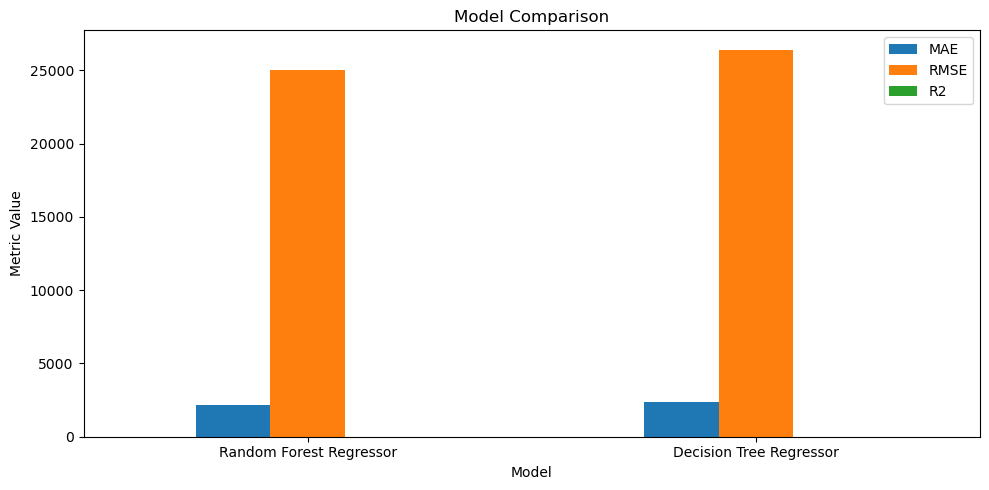

In [48]:
results_plot = results_df.set_index("Model")[["MAE", "RMSE", "R2"]]
results_plot.plot(kind="bar")
plt.title("Model Comparison")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Model evaluation and interpretation

### How the models are compared
The models are compared using:
- **MAE**: average absolute prediction error
- **RMSE**: penalises large errors more strongly
- **R²**: proportion of variance explained

### Expected interpretation
- The model with lower MAE and RMSE is better for prediction error.
- The model with higher R² explains more variance in waste tonnage.

Because the target is highly skewed and contains extreme values, RMSE is especially important because large mistakes matter.

In [53]:
comparison_preview = pd.DataFrame({
    "Actual Tonnes": np.expm1(y_test).values[:15],
    "Decision Tree Prediction": tree_pred[:15],
    "Random Forest Prediction": extra_pred[:15]
})

comparison_preview

,Actual Tonnes,Decision Tree Prediction,Random Forest Prediction
0,2.520,3.783438,4.376705
1,32.083,61.411272,52.694056
2,1184.989,274.642248,266.395953
3,1.500,2.145657,1.763089
4,2126.900,461.940236,433.832273
5,1427.740,5459.566937,3774.618812
6,0.220,1.344308,0.880603
7,0.812,4.507197,6.858430
8,5607.480,672.222396,2564.623191
9,276.000,26.175802,13.385657


## 8. Discussion of similarities and differences between the models

### Decision Tree
- Easy to explain
- Can capture nonlinear splits
- More interpretable
- Can overfit if not tuned

### Random Forest
- Uses many decision trees instead of just one
- More stable and accurate than a single decision tree
- Reduces overfitting by averaging multiple trees
- Can handle complex patterns and interactions in the data
- Less interpretable compared to a single decision tree

In this dataset, a multi-tree method is expected to be stronger because waste data contains many category interactions and non-linear effects.

## 9. Practical implications, limitations and conclusion

### Practical implications
Predicting annual waste tonnage can help:
- identify likely future waste pressure
- support capacity planning
- support resource allocation
- highlight waste categories or facilities linked to larger volumes

### Limitations
- Only four years of data are used
- Several columns are structurally missing depending on the waste stage
- The dataset is strongly skewed
- There may be operational or policy variables not included in these files
- The model predicts from recorded attributes only, not from external drivers

### Final conclusion
`Waste Quantity Tonnes per Year` is a valid regression target for this project.

The analysis shows:
- the data contains meaningful structure, but also heavy and partly structural missingness
- the target is highly skewed and benefits from log transformation
- binomial, Poisson and normal distributions each add useful statistical insight
- tree-based supervised learning models are appropriate for this regression task
- comparing two tuned models gives a clear basis for critical evaluation